# UM-CISC7107 Assignment 2 Tutorial

This notebook is a **companion** to `UM-CISC7107-assignment2.ipynb`.
Instead of repeating the assignment itself, it covers the tools and background that the main notebook moves through quickly.

It has four parts:
1. how to work comfortably in Colab
2. the PyTorch patterns that appear in Part 2
3. how to read Part 1: EDA and relation networks
4. a small end-to-end CNN pipeline for Part 2


## 1. Colab Basics

Colab is really two tools at once: a notebook editor and a temporary Linux machine in the cloud. The assignment uses both sides. Some cells explain ideas, some run Python, and a few use short shell commands to inspect files or the runtime.

Before working through the assignment notebook, make sure this workflow feels routine. In practice that means five things:
- running Python in **code cells**
- using `!` when you want a quick shell command inside the notebook
- writing explanations in **markdown cells**
- mounting **Google Drive** when you want files to persist
- checking whether the runtime is actually connected to a **GPU**

The key habit is simple: know which layer you are using. If you are doing Python, stay in normal code. If you want the notebook version of a terminal command like `pwd` or `ls`, add `!` at the front. If you want to explain what a cell is doing, switch to markdown.

Run this section once, just to make those mechanics feel familiar. If the device check later says `cpu`, go to **Runtime -> Change runtime type** and attach a GPU before starting the heavier Part 2 cells.


### Example Markdown Cell

This cell is itself a markdown cell. In the assignment notebook, markdown is not just decoration. It tells you what question a code block is answering, what part of the output matters, and what conclusion to keep in mind before moving on.

That is a good notebook habit in general: alternate short explanation cells with code cells, so the notebook reads like an argument instead of a dump of commands.

It supports:
- **bold text**
- *italic text*
- bullet lists
- `inline code`
- equations like $y = Wx + b$


### Markdown Syntax

You do not need advanced markdown for this course. Short headings, bullets, and a little inline code are enough.

In Colab, create a text cell with **+ Text** or change a cell from `Code` to `Text`, then you can write something like this:

```markdown
## Section Title

- **bold text**
- `inline code`
- equation: $y = Wx + b$
```


In [1]:
from pathlib import Path
import sys
import torch

print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"Working directory: {Path.cwd()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Detected device: {device}")
if device.type == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected. Part 2 will run, but it will be slower.")


Python version: 3.12.13
PyTorch version: 2.10.0+cu128
Working directory: /content
Detected device: cuda
GPU name: Tesla T4


In [2]:
!pwd
!ls -1
!python --version
!nvidia-smi || echo "No GPU visible to the shell."


/content
sample_data
Python 3.12.13
Mon Mar 30 09:07:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------

### Google Drive

In Colab, the runtime is temporary. The folder under `/content` behaves like scratch space on a remote machine: it is convenient while the session is alive, but it can disappear when the runtime resets or disconnects.

Google Drive is the simplest way to keep notebooks and downloaded files across sessions. After you mount it, `/content/drive/MyDrive` is usually the main place to save work you care about.

- The assignment notebook itself can live in Drive.
- Downloaded files can also be saved there.
- That makes Drive the safer place for anything you want to keep after the session ends.

A useful mental model is: `/content` is temporary working space, while Drive is persistent storage.


In [3]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Drive mounted.")
    print("Common root:", Path("/content/drive/MyDrive"))
except ImportError:
    print("This cell is meant for Google Colab. Skip it if you are running locally.")


Mounted at /content/drive
Drive mounted.
Common root: /content/drive/MyDrive


In [4]:
numbers = [2, 4, 6, 8]
squares = [n ** 2 for n in numbers]

def average(values):
    return sum(values) / len(values)

print("numbers:", numbers)
print("squares:", squares)
print("average:", average(numbers))
print("dictionary example:", {"min": min(numbers), "max": max(numbers)})


numbers: [2, 4, 6, 8]
squares: [4, 16, 36, 64]
average: 5.0
dictionary example: {'min': 2, 'max': 8}


## 2. Small PyTorch Tutorial

This section follows only the **assignment-relevant** parts of the Stanford **CS224N PyTorch Tutorial**:
[CS224N PyTorch Tutorial](https://web.stanford.edu/class/archive/cs/cs224n/cs224n.1214/materials/CS224N_PyTorch_Tutorial.html)

We keep the scope narrow. The assignment does not need the NLP-specific parts of that tutorial. What matters here is:
- tensor shape, dtype, and device
- `view()` / reshaping and adding a batch dimension
- `DataLoader` for batching
- autograd and why gradients accumulate
- `nn.Module`, `forward`, loss, optimizer, and one training step

The goal is not to teach all of PyTorch. It is to make the Part 2 code readable.


### 2.1 Tensor Basics: Shape, Dtype, and Device

In Part 2, most of the data starts life as image tensors. The important habit is to read shapes fluently:
- a single CIFAR-10 image has shape `(3, 32, 32)`
- a batch of images has shape `(batch, 3, 32, 32)`
- class labels for classification are integer tensors, usually `torch.long`

Once those shapes feel natural, the rest of the CNN pipeline is much easier to follow.


In [5]:
base = torch.tensor([[1, 2], [3, 4], [5, 6]], dtype=torch.float32)
print("base tensor:")
print(base)
print("dtype:", base.dtype)
print("shape:", tuple(base.shape))
print("numel:", base.numel())

single_image = torch.randn(3, 32, 32)
print("single image shape:", tuple(single_image.shape))

batched_image = single_image.unsqueeze(0)
print("after unsqueeze for batch dimension:", tuple(batched_image.shape))


base tensor:
tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])
dtype: torch.float32
shape: (3, 2)
numel: 6
single image shape: (3, 32, 32)
after unsqueeze for batch dimension: (1, 3, 32, 32)


In [6]:
x = torch.arange(12, dtype=torch.float32)
print("flat tensor:", x)

x_view = x.view(3, 4)
print("view as 3x4:")
print(x_view)

x_reshaped = x.reshape(2, 6)
print("reshape as 2x6:")
print(x_reshaped)

x_device = x_view.to(device)
print("device after .to(device):", x_device.device)


flat tensor: tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])
view as 3x4:
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])
reshape as 2x6:
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.],
        [ 6.,  7.,  8.,  9., 10., 11.]])
device after .to(device): cuda:0


### 2.2 DataLoader: Why We Batch Data

The assignment notebook trains on mini-batches rather than one example at a time. A `DataLoader` handles that batching for us, and can reshuffle the training data each epoch.

The main idea is simple: instead of passing one image to the model, we pass a batch shaped like `(batch, 3, 32, 32)`.


In [7]:
from torch.utils.data import TensorDataset, DataLoader

features = torch.randn(12, 3, 32, 32)
labels = torch.randint(0, 10, (12,), dtype=torch.long)

dataset = TensorDataset(features, labels)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

x_batch, y_batch = next(iter(loader))
print("x_batch shape:", tuple(x_batch.shape))
print("y_batch shape:", tuple(y_batch.shape))
print("label dtype:", y_batch.dtype)
print("A DataLoader gives one batch at a time.")


x_batch shape: (4, 3, 32, 32)
y_batch shape: (4,)
label dtype: torch.int64
A DataLoader gives one batch at a time.


### 2.3 Autograd: Why `backward()` and `zero_grad()` Matter

PyTorch can automatically compute gradients for tensors with `requires_grad=True`. When we call `backward()`, those gradients are written into `.grad`.

The detail that matters in practice is that gradients accumulate. If we do not reset them, the next backward pass adds on top of the old values. That is why training loops call `zero_grad()` before each parameter update.


In [8]:
x = torch.tensor([2.0], requires_grad=True)
print("gradient before backward:", x.grad)

y = 3 * x * x
y.backward()
print("gradient after first backward:", x.grad)

z = 3 * x * x
z.backward()
print("gradient after second backward:", x.grad)
print("In real training, optimizer.zero_grad() prevents this accumulation from carrying across steps.")


gradient before backward: None
gradient after first backward: tensor([12.])
gradient after second backward: tensor([24.])
In real training, optimizer.zero_grad() prevents this accumulation from carrying across steps.


### 2.4 `nn.Module`, Loss, Optimizer, and One Training Step

This is the core pattern that appears again in Part 2 of the assignment:
1. define a model
2. move data and model to the same device
3. call `model.train()`
4. run `zero_grad -> forward -> loss -> backward -> step`
5. switch to `model.eval()` for evaluation

If you can read this five-step pattern, you can read most of the training code in the main notebook.


In [9]:
from torch import nn

class TinyClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 32),
            nn.ReLU(),
            nn.Linear(32, 10),
        )

    def forward(self, x):
        return self.net(x)

model = TinyClassifier().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

model.train()
optimizer.zero_grad()
logits = model(x_batch)
loss = loss_fn(logits, y_batch)
loss.backward()
optimizer.step()

print("logits shape:", tuple(logits.shape))
print("loss:", float(loss))
print("training mode:", model.training)

model.eval()
with torch.no_grad():
    eval_logits = model(x_batch)
print("eval mode:", model.training)
print("eval logits shape:", tuple(eval_logits.shape))


logits shape: (4, 10)
loss: 2.516733169555664
training mode: True
eval mode: False
eval logits shape: (4, 10)


/tmp/ipykernel_17672/2230504730.py:31: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("loss:", float(loss))


## 3. EDA Background for the Assignment

Before looking at the real Part 1 datasets, it helps to strip the idea down to a very small example. So this section uses a toy table made inside the notebook.

The goal is just to make the Part 1 workflow easy to read:
1. identify the target type
2. choose a sensible first plot
3. compute Spearman correlations
4. turn those correlations into a **relation network**

This section focuses on three concrete ideas from Part 1:
- how to read the **first plot** for each dataset
- how to interpret a **Spearman correlation** value
- how those correlations become a **relation network**


In [10]:
import pandas as pd

toy_df = pd.DataFrame({
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8],
    "sleep_hours": [5, 5, 6, 6, 7, 7, 8, 8],
    "stress_level": [9, 8, 8, 7, 6, 6, 5, 4],
    "exam_score": [48, 52, 58, 63, 69, 74, 80, 86],
})
toy_df["passed"] = ["Pass" if score >= 65 else "Not pass" for score in toy_df["exam_score"]]

print(toy_df)
print()
print("Each row is one student.")
print("Continuous target: exam_score")
print("Binary target: passed")
print("That target choice tells us what first plot makes sense.")


   study_hours  sleep_hours  stress_level  exam_score    passed
0            1            5             9          48  Not pass
1            2            5             8          52  Not pass
2            3            6             8          58  Not pass
3            4            6             7          63  Not pass
4            5            7             6          69      Pass
5            6            7             6          74      Pass
6            7            8             5          80      Pass
7            8            8             4          86      Pass

Each row is one student.
Continuous target: exam_score
Binary target: passed
That target choice tells us what first plot makes sense.


### 3.1 How to read the first plot

The **target type** drives the first plot.

Here we use the same toy table in two different ways.
- When the target is the continuous `exam_score`, a **scatter plot** is the natural first look.
- When the target is the binary `passed`, a **box plot** makes more sense.

What to look for:
- In a scatter plot, ask whether the points rise, fall, or look random.
- In a box plot, ask whether the two groups are separated or heavily overlapping.

That is exactly why the assignment starts its two real datasets differently, even though both later end in a relation network.


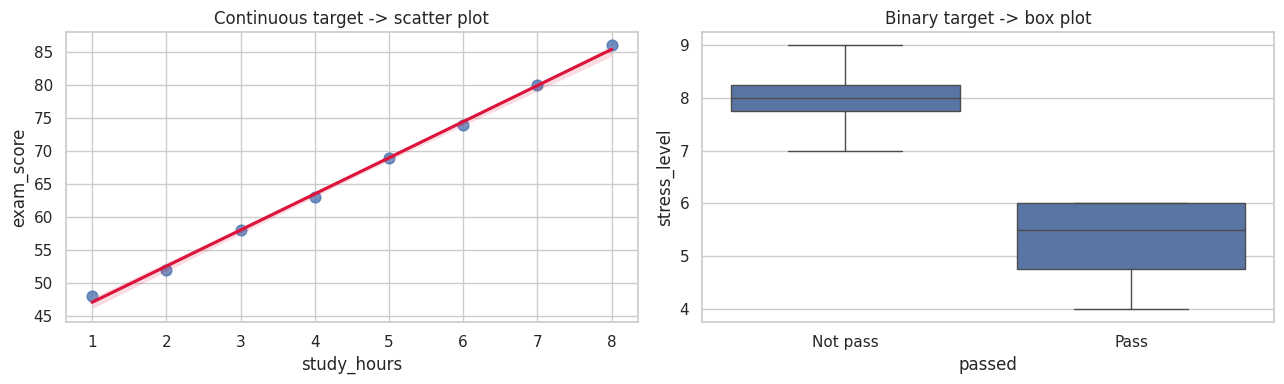

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.regplot(
    data=toy_df,
    x="study_hours",
    y="exam_score",
    ax=axes[0],
    scatter_kws={"s": 60, "alpha": 0.8},
    line_kws={"color": "crimson"},
)
axes[0].set_title("Continuous target -> scatter plot")
axes[0].set_xlabel("study_hours")
axes[0].set_ylabel("exam_score")

sns.boxplot(data=toy_df, x="passed", y="stress_level", order=["Not pass", "Pass"], ax=axes[1])
axes[1].set_title("Binary target -> box plot")
axes[1].set_xlabel("passed")
axes[1].set_ylabel("stress_level")

plt.tight_layout()
plt.show()


### 3.2 One concrete example: Spearman correlation

Throughout Part 1, the assignment uses **Spearman's rank correlation (ρ)** to measure association. It ranges from −1 to +1 and asks a simple question: when one variable goes up, does the other also tend to go up or down?

The rough interpretation is:
- close to `+1`: strong positive association
- close to `-1`: strong negative association
- close to `0`: weak association

In the next cell we measure each toy feature against `exam_score`, then we measure the features against each other. Those two results are exactly what the relation network needs.


In [12]:
network_cols = [
    "study_hours",
    "sleep_hours",
    "stress_level",
    "exam_score",
]

corr_matrix = toy_df[network_cols].corr(method="spearman")
spearman_to_target = corr_matrix["exam_score"].drop("exam_score")

target_edges = spearman_to_target.reset_index()
target_edges.columns = ["feature", "rho"]
target_edges = target_edges.sort_values("rho", key=lambda s: s.abs(), ascending=False)
print("Solid edges: feature -> exam_score")
print(target_edges.round(3).to_string(index=False))
print()

feature_feature_corr = corr_matrix.drop(index="exam_score", columns="exam_score")
pair_rows = []
feature_names = list(feature_feature_corr.columns)
for i, left in enumerate(feature_names):
    for right in feature_names[i + 1:]:
        rho = float(feature_feature_corr.loc[left, right])
        pair_rows.append({"feature_a": left, "feature_b": right, "rho": rho})

pair_edges = pd.DataFrame(pair_rows)
pair_edges = pair_edges[pair_edges["rho"].abs() > 0.4].copy()
pair_edges = pair_edges.sort_values("rho", key=lambda s: s.abs(), ascending=False)
print("Dashed edges: feature <-> feature")
print(pair_edges.round(3).to_string(index=False))


Solid edges: feature -> exam_score
     feature    rho
 study_hours  1.000
stress_level -0.988
 sleep_hours  0.976

Dashed edges: feature <-> feature
  feature_a    feature_b    rho
study_hours stress_level -0.988
study_hours  sleep_hours  0.976
sleep_hours stress_level -0.963


### 3.3 How the relation network is built

Once those correlations are computed, the network is straightforward to build.

Put the target in the center. Then:
- each row in `target_edges` becomes one **solid** edge to the target
- each row in `pair_edges` becomes one **dashed** edge between two features
- larger `|ρ|` means a thicker edge

The solid edges answer: **which features matter for the outcome?**
The dashed edges answer: **which features travel together?**

So when you read the finished graph:
- a thick solid edge means a feature is strongly associated with the outcome
- a thick dashed edge means two features travel together
- a cluster suggests overlapping information
- an isolated feature may carry more distinct information


## 4. Mini CNN Procedure

Part 2 moves from named tabular features to raw pixels. That changes the workflow. Instead of asking which human-readable column matters most, we build an image pipeline: load images, batch them, define a CNN, train it, and inspect a few predictions.

This section is a smaller version of that pipeline. It is not a replacement for the full assignment notebook, but it shows the main ideas once in a simpler setting:
1. load image data
2. build a DataLoader
3. define a CNN
4. track how tensor shapes change through the model
5. run a short training loop
6. evaluate on a validation split


### 4.1 What data are we using?

For this demo we use **CIFAR-10**, the same kind of small image-classification setup used in Part 2.

Important facts:
- It contains **10 classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.
- Each example is a **color image** with size **32 x 32** pixels.
- In raw image form, you can think of one image as `32 x 32 x 3` because it has red, green, and blue channels.
- After `transforms.ToTensor()`, PyTorch stores the same image as a tensor with shape `(3, 32, 32)`.
- The label is an **integer class index** from 0 to 9.

So one dataset item has the form:
- `image_tensor`: a float tensor
- `label_index`: an integer class id

For lecture speed, we do **not** train on the full dataset. We take a small subset from the CIFAR-10 training split, then divide that subset into a small training set and a small validation set.


100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


Full CIFAR-10 training split size: 50000
Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Type of one image object: <class 'torch.Tensor'>
One image tensor shape: (3, 32, 32)
One image dtype: torch.float32
Pixel range after ToTensor(): 0.0 to 1.0
One label index: 6
One label name: frog

Lecture demo split:
Train subset size: 512
Val subset size: 128
Total examples used in this mini demo: 640

A DataLoader returns batches, not single images.
Batch image shape: (64, 3, 32, 32)
Batch label shape: (64,)
Batch image dtype: torch.float32
Batch label dtype: torch.int64
First five class names in this batch: ['truck', 'frog', 'bird', 'bird', 'automobile']


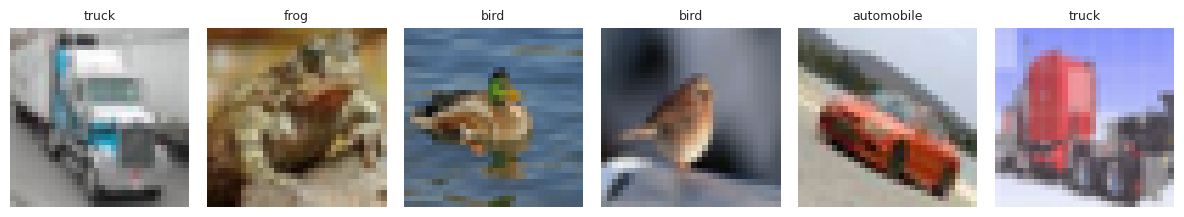

In [13]:
from torchvision import datasets, transforms
from torch.utils.data import Subset

transform = transforms.Compose([
    transforms.ToTensor(),
])

full_train = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)

sample_image, sample_label = full_train[0]
class_names = full_train.classes
print("Full CIFAR-10 training split size:", len(full_train))
print("Number of classes:", len(class_names))
print("Class names:", class_names)
print()
print("Type of one image object:", type(sample_image))
print("One image tensor shape:", tuple(sample_image.shape))
print("One image dtype:", sample_image.dtype)
print("Pixel range after ToTensor():", float(sample_image.min()), "to", float(sample_image.max()))
print("One label index:", sample_label)
print("One label name:", class_names[sample_label])

# Small subset for a quick lecture demo
seed = 7107
g = torch.Generator().manual_seed(seed)
indices = torch.randperm(len(full_train), generator=g).tolist()
train_indices = indices[:512]
val_indices = indices[512:640]

train_dataset = Subset(full_train, train_indices)
val_dataset = Subset(full_train, val_indices)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

example_images, example_labels = next(iter(train_loader))
print()
print("Lecture demo split:")
print("Train subset size:", len(train_dataset))
print("Val subset size:", len(val_dataset))
print("Total examples used in this mini demo:", len(train_dataset) + len(val_dataset))
print()
print("A DataLoader returns batches, not single images.")
print("Batch image shape:", tuple(example_images.shape))
print("Batch label shape:", tuple(example_labels.shape))
print("Batch image dtype:", example_images.dtype)
print("Batch label dtype:", example_labels.dtype)
print("First five class names in this batch:", [class_names[int(y)] for y in example_labels[:5]])

fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))
for ax, img, label in zip(axes, example_images[:6], example_labels[:6]):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(class_names[int(label)], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


### 4.2 What should the model output?

This is a **10-class classification** problem, so the model must output **10 numbers per image**.

Those 10 numbers are called **logits**:
- one logit for each class
- a larger logit means the model currently prefers that class more
- logits are not yet probabilities
- the predicted class is just the index of the largest logit

So if the input batch has shape `(64, 3, 32, 32)`, the final output should have shape `(64, 10)`.


### 4.3 What each CNN layer is doing

The model is split into two pieces:
- `features`: convolution and pooling layers that turn pixels into learned feature maps
- `classifier`: fully connected layers that map those learned features to 10 class logits

Layer by layer:
- `Conv2d(3, 16, kernel_size=3, padding=1)` reads the 3 color channels and produces 16 learned feature maps.
- `ReLU()` keeps positive activations and adds non-linearity.
- `MaxPool2d(2)` halves the height and width, so `32 x 32` becomes `16 x 16`.
- The second convolution grows the channel count from 16 to 32.
- The second pooling step halves the spatial size again, so `16 x 16` becomes `8 x 8`.
- `Flatten()` converts `32 x 8 x 8` into one vector of length `32*8*8 = 2048`.
- The linear layers convert that vector into the final 10 logits.

This is the same high-level logic as the larger CNN in the assignment notebook. The only difference here is that we keep the example smaller.


In [14]:
class MiniCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

mini_cnn = MiniCNN().to(device)
print(mini_cnn)
print()
demo_logits = mini_cnn(example_images[:4].to(device))
print("Output shape for 4 input images:", tuple(demo_logits.shape))


MiniCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)

Output shape for 4 input images: (4, 10)


### 4.4 Why we trace tensor shapes

In CNN code, many beginner errors are really **shape errors**.

The point of the next cell is to make the shape changes explicit:
- the input starts as `(batch, channels, height, width)`
- convolutions keep spatial size here because we used `padding=1`
- pooling reduces spatial size
- flattening removes the spatial structure and produces one feature vector per image
- the final output shape `(batch, 10)` matches the number of classes


In [15]:
shape_x = example_images[:4].to(device)
print("input:", tuple(shape_x.shape))

with torch.no_grad():
    z = shape_x
    for name, layer in mini_cnn.features.named_children():
        z = layer(z)
        print(f"features[{name}] -> {tuple(z.shape)}")

    z = mini_cnn.classifier[0](z)
    print("flatten ->", tuple(z.shape))
    z = mini_cnn.classifier[1](z)
    print("linear 1 ->", tuple(z.shape))
    z = mini_cnn.classifier[2](z)
    print("relu ->", tuple(z.shape))
    z = mini_cnn.classifier[3](z)
    print("linear 2 / logits ->", tuple(z.shape))


input: (4, 3, 32, 32)
features[0] -> (4, 16, 32, 32)
features[1] -> (4, 16, 32, 32)
features[2] -> (4, 16, 16, 16)
features[3] -> (4, 32, 16, 16)
features[4] -> (4, 32, 16, 16)
features[5] -> (4, 32, 8, 8)
flatten -> (4, 2048)
linear 1 -> (4, 64)
relu -> (4, 64)
linear 2 / logits -> (4, 10)


### 4.5 What happens during training?

Each batch goes through the same sequence:
1. move images and labels to the chosen device
2. clear old gradients with `zero_grad()`
3. compute logits with a forward pass
4. compare logits with the true labels using `CrossEntropyLoss`
5. run `backward()` to compute gradients
6. run `optimizer.step()` to update the model parameters

During validation, we still compute logits and loss, but we do **not** update parameters.
That is the same train/eval split used throughout the assignment.


In [16]:
mini_loss_fn = nn.CrossEntropyLoss()
mini_optimizer = torch.optim.Adam(mini_cnn.parameters(), lr=1e-3)

def run_epoch(model, loader, train_mode):
    model.train(train_mode)
    total_loss = 0.0
    total_correct = 0
    total_items = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if train_mode:
            mini_optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(images)
            loss = mini_loss_fn(logits, labels)

            if train_mode:
                loss.backward()
                mini_optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_items += labels.size(0)

    return total_loss / total_items, total_correct / total_items

for epoch in range(1, 3):
    train_loss, train_acc = run_epoch(mini_cnn, train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(mini_cnn, val_loader, train_mode=False)
    print(
        f"epoch {epoch}: "
        f"train loss={train_loss:.4f}, train acc={train_acc:.3f}, "
        f"val loss={val_loss:.4f}, val acc={val_acc:.3f}"
    )


epoch 1: train loss=2.2963, train acc=0.109, val loss=2.3215, val acc=0.078
epoch 2: train loss=2.2685, train acc=0.166, val loss=2.2857, val acc=0.133


### 4.6 Reading the predictions

After a short training run, we look at a few validation images.

Each title shows:
- `T:` the **true** class
- `P:` the model's **predicted** class

This is the first layer of evaluation.
Even before advanced interpretation tools such as Grad-CAM, it is worth checking a handful of predictions directly and asking whether the model's mistakes look sensible.


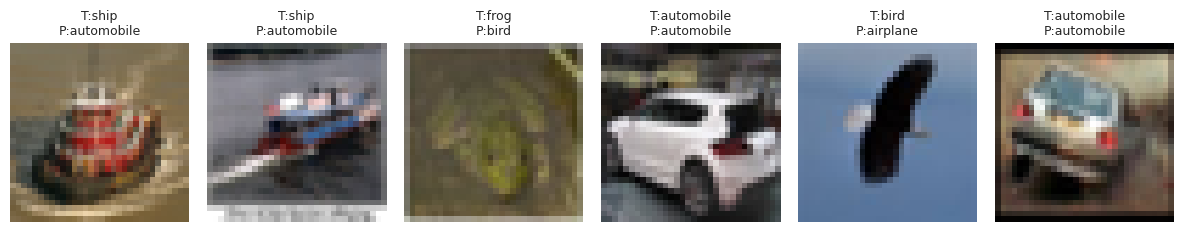

In [17]:
mini_cnn.eval()
images, labels = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    preds = mini_cnn(images).argmax(dim=1).cpu()

fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))
for ax, img, true_y, pred_y in zip(axes, images.cpu()[:6], labels[:6], preds[:6]):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(f"T:{class_names[int(true_y)]}\nP:{class_names[int(pred_y)]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()
